<a href="https://colab.research.google.com/github/aditya03bairagi/Data-Science-Projects/blob/main/P2_Product_Purchase_Prediction_Using_Social_Network_Advertisements.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Problem Statement:**

1. Companies spend too much money on social network advertisements to promote their products.
2. It is difficult to identify which users are likely to purchase the product.
3. The dataset contains user information such as **User ID, Gender, Age, and Estimated Salary**.
4. The target variable **Purchased** is already in binary format:

   * **1** = User will purchase the product
   * **0** = User will not purchase the product
5. The objective is to build a machine learning classification model that predicts whether a user will purchase the product or not.
6. This can help companies improve advertisement targeting and marketing strategies.





In [ ]:
# Product Purchase Prediction Using Social Network Advertisements

# import libraries
import pandas as pd # for data analysis
import numpy as np # for mathematical computations
import matplotlib.pyplot as plt # for data visualization
import seaborn as sb # for data visualization

from sklearn.preprocessing import OneHotEncoder, StandardScaler # For Encoding and Scaling
from sklearn.model_selection import train_test_split, GridSearchCV  # For train-test split, GridSearchCV for hyperparameter tuning
from sklearn.compose import ColumnTransformer # ColumnTransformer: to apply different transform to different columns in a single step
from sklearn.pipeline import Pipeline # Pipeline: to chain preprocessing + model
from sklearn.neighbors import KNeighborsClassifier # For KNN model
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score # metrics to evaluate the model performance


In [ ]:
# Download the data from kaggle using kagglehub api
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rakeshrau/social-network-ads")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'social-network-ads' dataset.
Path to dataset files: /kaggle/input/social-network-ads


In [ ]:
# 1) Load the data
df = pd.read_csv('/kaggle/input/social-network-ads/Social_Network_Ads.csv')

df.head() # returns top 5 rows

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
# 2) EDA (Exploratory Data Analysis): Data Exploration, Data Visualization, Data Cleaning
# 2.1) Data Exploration:
# dataset information
df.shape # no. of rows, no. of columns


(400, 5)

In [ ]:
df.info() # column name, non-null count, datatype

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [ ]:
# statistical analysis
df.describe() # count, mean, std, min, 25%, 50%, 75%, max

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [ ]:
# Column Names
df.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [ ]:
# check for duplicate columns
df.T.duplicated().sum() # returns the number of duplicate columns in a DataFrame.

np.int64(0)

In [ ]:
# Check Missing Values
df.isna().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


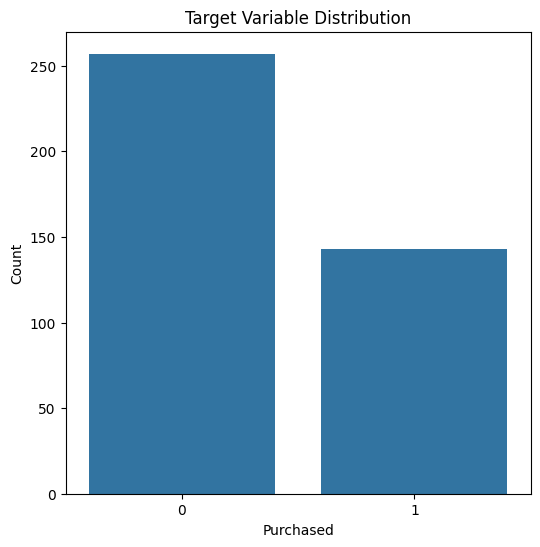

In [ ]:
# 2.2) Data Visualization
# target variable Distribution
# Count of each category:
plt.figure(figsize=(6,6))
sb.countplot(x='Purchased', data=df)
plt.title('Target Variable Distribution')
plt.xlabel('Purchased')
plt.ylabel('Count')
plt.show()


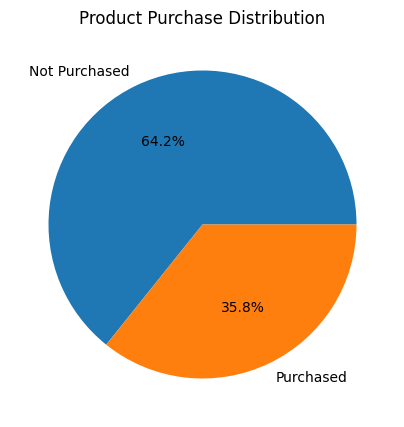

In [ ]:
# Pie chart for target distribution
plt.figure(figsize=(5,5))
purchase_count = df['Purchased'].value_counts()
plt.pie(purchase_count, labels=['Not Purchased', 'Purchased'], autopct='%1.1f%%')
plt.title('Product Purchase Distribution')
plt.show()


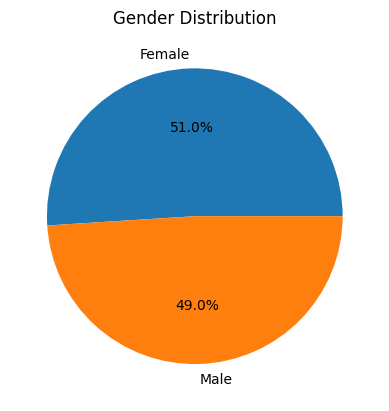

In [ ]:
# Gender Distribution
gender_counts = df['Gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.show()


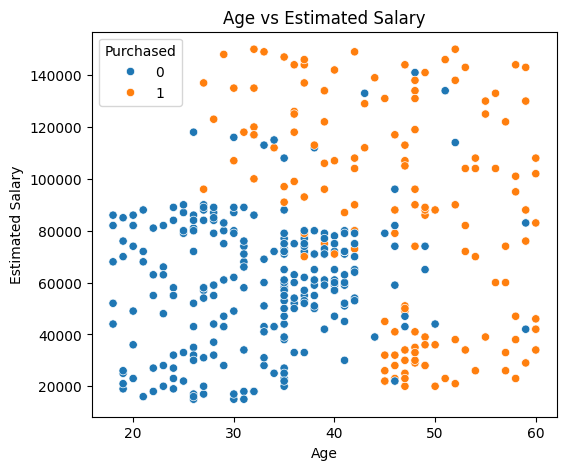

In [ ]:
# Scatterplot
plt.figure(figsize=(6,5))
sb.scatterplot(x='Age', y='EstimatedSalary', hue='Purchased', data=df)
plt.title('Age vs Estimated Salary')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.show()

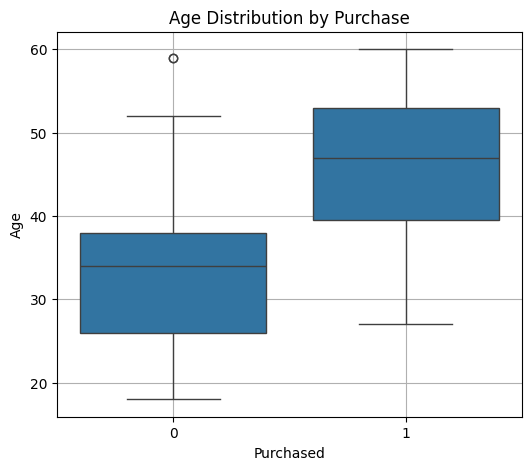

In [ ]:
# Boxplot for outliers detection
plt.figure(figsize=(6,5))
sb.boxplot(x='Purchased', y='Age', data=df)
plt.title('Age Distribution by Purchase')
plt.xlabel('Purchased')
plt.ylabel('Age')
plt.grid()
plt.show()

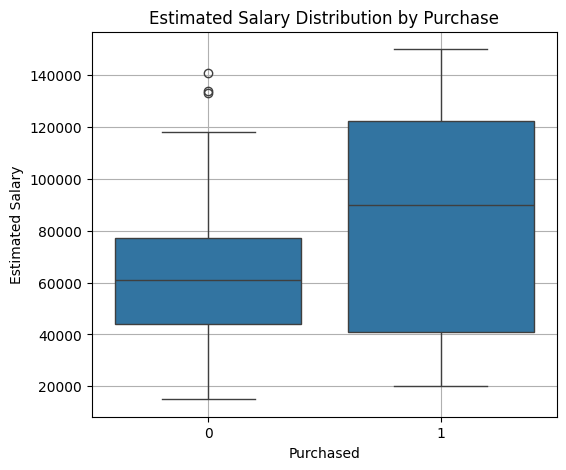

In [ ]:
# Box plot for outliers detection
plt.figure(figsize=(6,5))
sb.boxplot(x='Purchased', y='EstimatedSalary', data=df)
plt.xlabel('Purchased')
plt.ylabel('Estimated Salary')
plt.title('Estimated Salary Distribution by Purchase')
plt.grid()
plt.show()

In [ ]:
# 2.3) Data Cleaning: Encoding, Scaling, Remove irrelavent features.
# Remove irrelavent column from dataset
df = df.drop('User ID', axis=1)

In [ ]:
# 3) Feature Selection
X = df.drop('Purchased', axis=1) # select all columns except target variable
y = df['Purchased'] # select target variable


In [ ]:
# 4) Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                 # inputs(X), output(y)
    test_size=0.2,        # test_size=20%, training_size=80%
    random_state=42,      # for reproducibility of same results everytime
    stratify=y            # for equal distribution of train_size and test_size during training, testing and evaluation.
)


In [ ]:
# 5) Column Transformer: one-hot encode gender, scale numeric features

preprocessor = ColumnTransformer([
    ('encode', OneHotEncoder(drop='first'), ['Gender']),  # for encoding
    ('scale', StandardScaler(), ['Age', 'EstimatedSalary']) # for scaling
])

# ColumnTransformer applies different transformations (such as scaling and encoding)
# to different columns in a single preprocessing step.


In [ ]:
# 6) Pipeline for chaining preprocessing and model

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

# Pipeline → Applies a sequence of steps one after another.

# Example: Preprocessing → Model Training

# Pipeline chains the preprocessing steps (encoding/scaling) and the model
# into a single object. This ensures that the data transformation
# and modeling workflow is handled automatically and consistently.


In [ ]:
# Hyperparameter Tuning:
# Hyperparameter tuning is the process of finding the best values of a model's hyperparameters
#  to improve model performance.

# Why do we do Hyperparameter Tuning?
# Different hyperparameter values produce different model performance.
# Hyperparameter tuning helps us find the combination that gives the best model performance.

# Hyperparameters grid
# A hyperparameter grid is a dictionary that contains different values of hyperparameters
# to be tested during hyperparameter tuning.

param_grid = {
    'model__n_neighbors': [3, 5, 7, 9, 11],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan']
}

# Hyperparameters explanation:

# model__ → Refers to the KNN model step in the pipeline.
# The double underscore (__) is used to access the model's hyperparameters.

# 1. n_neighbors → The number of nearest neighbors (k) that KNN considers for prediction.

# 2. weights → Determines how neighbors vote during prediction.

  # uniform → Every neighbor gets one equal vote, regardless of its distance.
  # distance → Every neighbor votes, but closer neighbors have more voting power, while farther neighbors have less.

  # Example:
  # Nearest neighbors:
  # Very close → Class A
  # Far → Class B
  # Far → Class B
  # Uniform: A = 1 vote, B = 2 votes → Prediction = B
  # Distance: The vote from the very close neighbor has more weight than the two farther votes, so Prediction may become A.
# Note: The term voting is used for KNN classification.

# 3. metric → The distance metric used to find the nearest neighbors.
  # euclidean → Straight-line distance.
  # manhattan → Distance measured by horizontal and vertical moves.
  # _________________________________________________________________________________________________

# GridSearchCV
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy'
)

# GridSearchCV
# GridSearchCV is a technique used for hyperparameter tuning.
# It automatically tests all possible combinations of hyperparameter values
# and selects the best combination to achieve the best model performance using cross-validation.

# _________________________________________________________________________________________________

# Cross-Validation (CV):
# Cross-validation is a technique used to evaluate a model,
# by training and testing it on different subsets (folds) of the data.

# Example (5-Fold Cross-Validation):

# 1. Split the dataset into 5 equal folds.
# 2. Train the model on 4 folds and test it on 1 fold.
# 3. Repeat this process 5 times, so each fold is used as the test set once.
# 4. Take the average of the 5 scores as the final performance.

# Why do we use Cross-Validation?
# To obtain a more reliable estimate of model performance.


In [ ]:
# 7) Train the knn model
grid.fit(X_train, y_train) # fit() method is used to train the model


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('encode',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['Gender']),
                                                                        ('scale',
                                                                         StandardScaler(),
                                                                         ['Age',
                                                                          'EstimatedSalary'])])),
                                       ('model', KNeighborsClassifier())]),
             param_grid={'model__metric': ['euclidean', 'manhattan'],
                         'model__n_neighbors': [3, 5, 7, 9, 11],
                         'model__weights': ['uniform', 'distance']},
             scoring='accuracy')

In [ ]:
print('Best Parameters:\n', grid.best_params_)
# best_params_ returns the best combination of hyperparameter values found by GridSearchCV.

print('--' * 50)

best_knn = grid.best_estimator_
# best_estimator_ returns the best trained model found by GridSearchCV using the best combination of hyperparameters.

print('Best KNN Model: ', best_knn)

Best Parameters:
 {'model__metric': 'euclidean', 'model__n_neighbors': 7, 'model__weights': 'uniform'}
----------------------------------------------------------------------------------------------------
Best KNN Model:  Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('encode',
                                                  OneHotEncoder(drop='first'),
                                                  ['Gender']),
                                                 ('scale', StandardScaler(),
                                                  ['Age',
                                                   'EstimatedSalary'])])),
                ('model',
                 KNeighborsClassifier(metric='euclidean', n_neighbors=7))])


In [ ]:
# 8) Test the model (Make predictions)
y_pred = best_knn.predict(X_test) # predict() method is used to test the model


In [ ]:
# 9) Evaluate the model performance
# Accuracy:
print('Accuracy: ', accuracy_score(y_test, y_pred))

'''
Accuracy:
Accuracy focuses on, out of all the predictions made by the model,
how many were correctly predicted.

Accuracy = Correct Predictions / Total Predictions.

Accuracy = TP + TN / TP + TN + FP + FN​

Where:

TP = True Positives
TN = True Negatives
FP = False Positives
FN = False Negatives

'''
# Precision
print('Precision: ', precision_score(y_test, y_pred))


'''
Precision:
Precision: Of all predicted positives, how many were actually correct?

Precision focuses on, out of all the positive predictions made by the model,
how many were actually positive.

You should prioritize precision if:

1. A "False Alarm" causes an expensive or annoying problem.
2. The user's trust is easily broken by wrong predictions.
3. There is a punishment or heavy cost associated with being wrong.

Precision = TP / FP + TP​

'''

# Recall
print('Recall: ', recall_score(y_test, y_pred))

'''
Recall:

Recall: Of all actual positives, how many did the model correctly find?

Recall focuses on, out of the total actual positive cases,
how many the model correctly predicted as positive,
even if some negative cases are incorrectly predicted as positive.

You should prioritize recall if:

1. A "Miss" is dangerous or life-threatening.
2. False Alarms are annoying but manageable.
3. The goal is completeness, not necessarily efficiency.

Recall = TP / TP + FN​

'''
# f1score: Balanced measure of precision and recall.
print("F1 Score: ", f1_score(y_test, y_pred))

'''
F1-Score:
F1-Score measures the balance between Precision and Recall.

F1-Score tells us how well the model balances,
making correct positive predictions and finding actual positive cases.

F1-Score = 2 * (Precision * Recall) / (Precision + Recall)​

'''
# Confusion Matrix: shows the count of correct and incorrect predictions.
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

'''
# Understanding the Confusion Matrix (Through Human Confusion)

As human beings, we often face situations where we are uncertain and must choose between different options. For example:

* Should I say Yes or No?
* Is this right or wrong?
* Is this safe or unsafe?

When an AI model makes predictions, it also faces uncertainty. However, instead of expressing confusion, it organizes its decisions into clear categories by comparing its prediction with reality.

This comparison produces four possible outcomes:

* **True Positive (TP)** → AI predicted Positive, and it was actually Positive.
* **True Negative (TN)** → AI predicted Negative, and it was actually Negative.
* **False Positive (FP)** → AI predicted Positive, but it was actually Negative.
* **False Negative (FN)** → AI predicted Negative, but it was actually Positive.

### In Simple Words

* I correctly said **Yes** → True Positive
* I correctly said **No** → True Negative
* I wrongly said **Yes** → False Positive
* I wrongly said **No** → False Negative

This structured way of organizing correct and incorrect predictions is called a **Confusion Matrix**.

It helps us understand how well an AI model is performing by showing where it makes correct predictions and where it makes mistakes.

'''

# Classification Report: Summary of classification metrics
print('Classification Report:\n', classification_report(y_test, y_pred))


Accuracy:  0.9
Precision:  0.8387096774193549
Recall:  0.896551724137931
F1 Score:  0.8666666666666667
Confusion Matrix:
 [[46  5]
 [ 3 26]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.90      0.92        51
           1       0.84      0.90      0.87        29

    accuracy                           0.90        80
   macro avg       0.89      0.90      0.89        80
weighted avg       0.90      0.90      0.90        80



# **How KNN Works**

1. **Choose the value of `k`** (number of nearest neighbors).

2. **Training (`fit`)**

   * KNN **stores the training data (`X_train`) and their labels (`y_train`)**.
   * It does **not** build a mathematical model.

3. **Prediction (`predict`)**

   * When a new data point is given, KNN **calculates the distance** between the new point and all stored training data.
   * It **finds the `k` nearest neighbors** based on the selected distance metric (e.g., Euclidean or Manhattan).
   * It **takes a vote** among the `k` nearest neighbors.

     * **Classification:** The class with the **most votes** is predicted.
     * **Regression:** The **average** of the neighbors' values is predicted.

4. **Return the final prediction.**



---



### Example (Classification)

Suppose **`k = 5`** and the nearest neighbors are:

* Class A
* Class A
* Class B
* Class A
* Class B

**Voting:**

* Class A = 3 votes
* Class B = 2 votes

**Prediction = Class A**



---


### Flow:

```text
Choose k
    ↓
Store training data (fit)
    ↓
New data point
    ↓
Calculate distances
    ↓
Find k nearest neighbors
    ↓
Voting (Classification) / Averaging (Regression)
    ↓
Final Prediction
```


---



> **Note:** KNN is called a **lazy learning algorithm** because it **stores the training data during training** and performs most of the computation during prediction.


---


